<a href="https://colab.research.google.com/github/J-Eisenhauer/bern2/blob/main/Resampling_Ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# Ex Resampling, Jakob Eisenhauer

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

url = 'https://raw.githubusercontent.com/luchem/bern02/main/Labs/pollution_cleaneddata.csv'
data = pd.read_csv(url)

print(data.head())
print(data.columns)



   PREC  JANT  JULT  OVR65  POPN  EDUC  HOUS    DENS  NONW  WWDRK  POOR    HC  \
0  36.0  27.0  71.0    8.1  3.34  11.4  81.5  3243.0   8.8   42.6  11.7  21.0   
1  35.0  23.0  72.0   11.1  3.14  11.0  78.8  4281.0   3.5   50.7  14.4   8.0   
2  44.0  29.0  74.0   10.4  3.21   9.8  81.6  4260.0   0.8   39.4  12.4   6.0   
3  47.0  45.0  79.0    6.5  3.41  11.1  77.5  3125.0  27.1   50.2  20.6  18.0   
4  43.0  35.0  77.0    7.6  3.44   9.6  84.6  6441.0  24.4   43.7  14.3  43.0   

    NOX    SO@  HUMID      MORT  
0  15.0   59.0   59.0   921.870  
1  10.0   39.0   57.0   997.875  
2   6.0   33.0   54.0   962.354  
3   8.0   24.0   56.0   982.291  
4  38.0  206.0   55.0  1071.289  
Index(['PREC', 'JANT', 'JULT', 'OVR65', 'POPN', 'EDUC', 'HOUS', 'DENS', 'NONW',
       'WWDRK', 'POOR', 'HC', 'NOX', 'SO@', 'HUMID', 'MORT'],
      dtype='object')


60 pollution observations
            JULT         MORT
count  60.000000    60.000000
mean   74.583333   940.358433
std     4.763177    62.206278
min    63.000000   790.733000
25%    72.000000   898.372000
50%    74.000000   943.683000
75%    77.250000   983.205750
max    85.000000  1113.156000


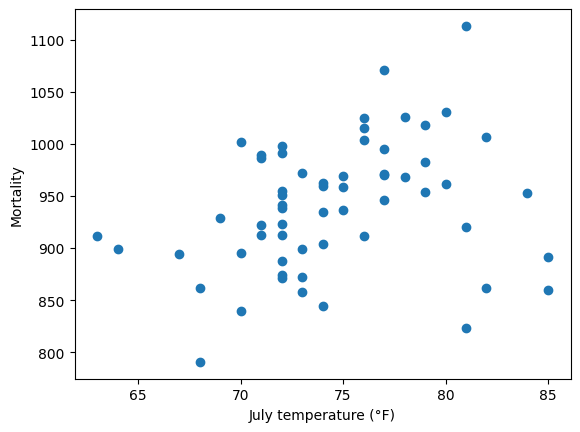

In [42]:
JULT = data['JULT']
JULT = np.array(JULT)
MORT = data['MORT']
MORT = np.array(MORT)

print(len(data), "pollution observations")
print(data[['JULT', 'MORT']].describe())

plt.scatter(JULT, MORT)
plt.xlabel('July temperature (°F)')
plt.ylabel('Mortality')
plt.show()

Mortality ($y_i$) as a polynomial function of the average July temperature in °F  ($x_i$) is modelled as a polynominal function: $$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \dots + \beta_p x_i^p + \varepsilon_i$$ with independent errors $\varepsilon_i \sim N(0, \sigma)$ and polynomial degree $p$ (here $p = 1, \dots, 4$), fitted by least squares.

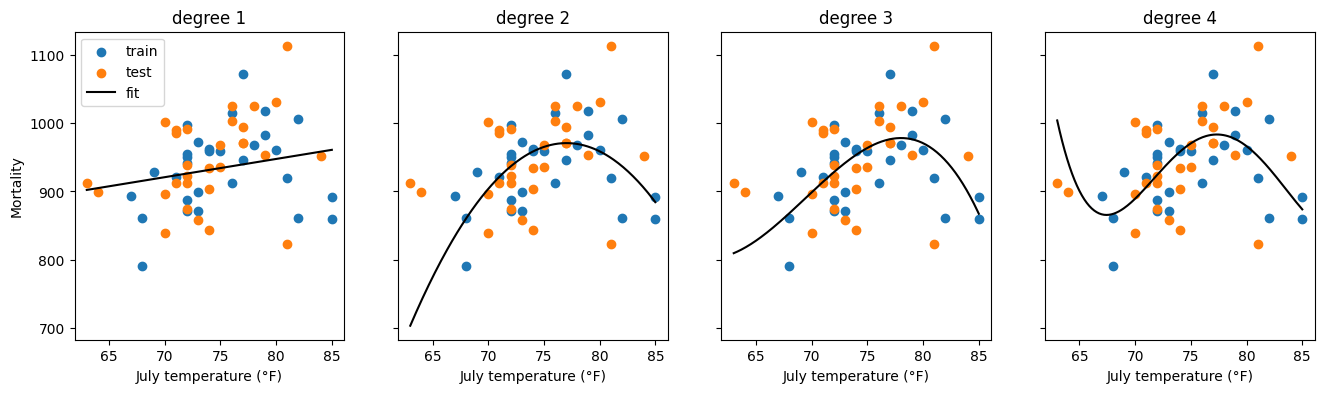

   degree    mse_train     mse_test
0       1  3244.023882  3927.829569
1       2  2053.188783  6089.295212
2       3  1969.428578  4249.153263
3       4  1932.635620  4208.497120


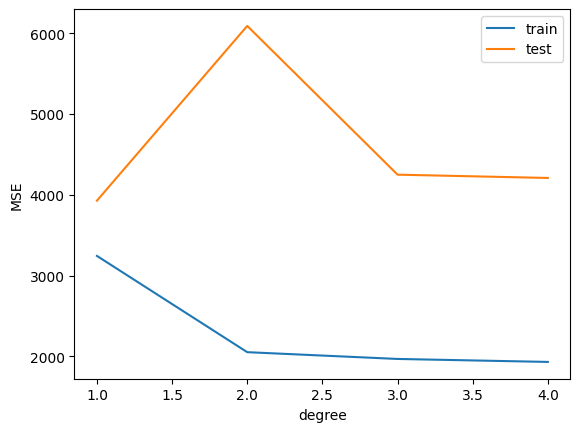

In [43]:
x = JULT
y = MORT

xc = x - x.mean()

def mse(y_true, y_pred):
  return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
  return np.sqrt(mse(y_true, y_pred))

def validation_split_errors(seed, degree_list):
  rng = np.random.default_rng(seed)
  index = rng.permutation(len(xc))
  train, test = index[:30], index[30:]

  mse_train=[]
  mse_test = []

  fig, ax = plt.subplots(1, len(degree_list), figsize=(16, 4), sharey=True)
  grid = np.linspace(xc.min(), xc.max(), 200)


  for i, p in enumerate(degree_list):
    coefs = np.polyfit(xc[train], y[train], p)
    y_pred_train = np.polyval(coefs, xc[train])
    y_pred_test = np.polyval(coefs, xc[test])
    mse_train.append(mse(y[train], y_pred_train))
    mse_test.append(mse(y[test], y_pred_test))

    ax[i].scatter(xc[train] + x.mean(), y[train], label='train')
    ax[i].scatter(xc[test] + x.mean(), y[test], label='test')
    ax[i].plot(grid + x.mean(), np.polyval(coefs, grid), color='k', label='fit')
    ax[i].set_title(f'degree {p}')
    ax[i].set_xlabel('July temperature (°F)')

  ax[0].set_ylabel('Mortality')
  ax[0].legend()
  plt.show()

  return np.array(mse_train), np.array(mse_test)

degree_list = [1,2,3,4]

mse_train, mse_test = validation_split_errors(123, degree_list)

print(pd.DataFrame({'degree': degree_list, 'mse_train': mse_train, 'mse_test': mse_test}))

plt.plot(degree_list, mse_train, label='train')
plt.plot(degree_list, mse_test, label='test')
plt.xlabel('degree')
plt.ylabel('MSE')
plt.legend()
plt.show()


With this specific seed degree 1 seems most reasonable. It has the smallest test error AND the smallest degree. However, that the train error still falls sharply in the degree 1->2 step indicates that degree 1 may only be the best fit for this specific seed.

------------------------------------------------------------
Seed 1
------------------------------------------------------------


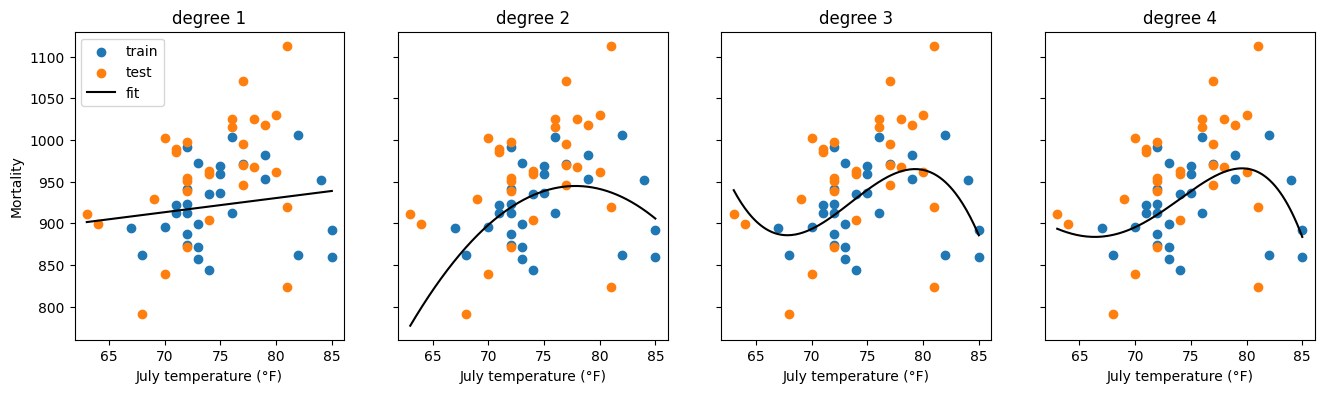

------------------------------------------------------------
Seed 2
------------------------------------------------------------


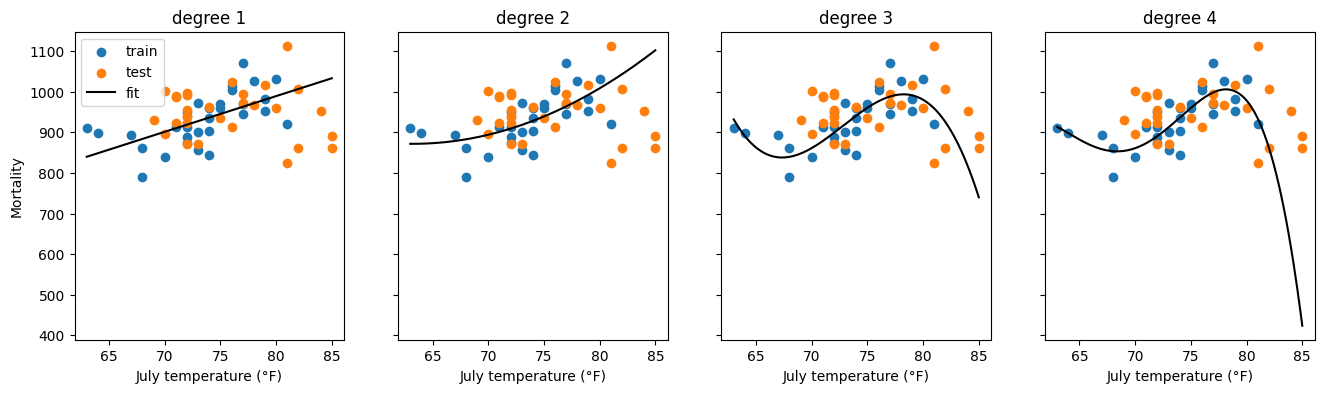

------------------------------------------------------------
Seed 3
------------------------------------------------------------


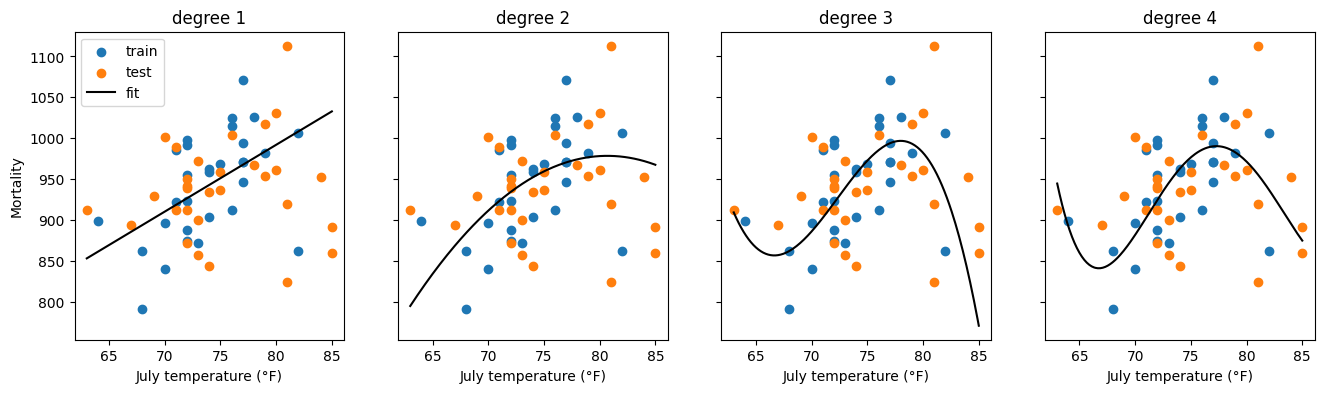

------------------------------------------------------------
Seed 4
------------------------------------------------------------


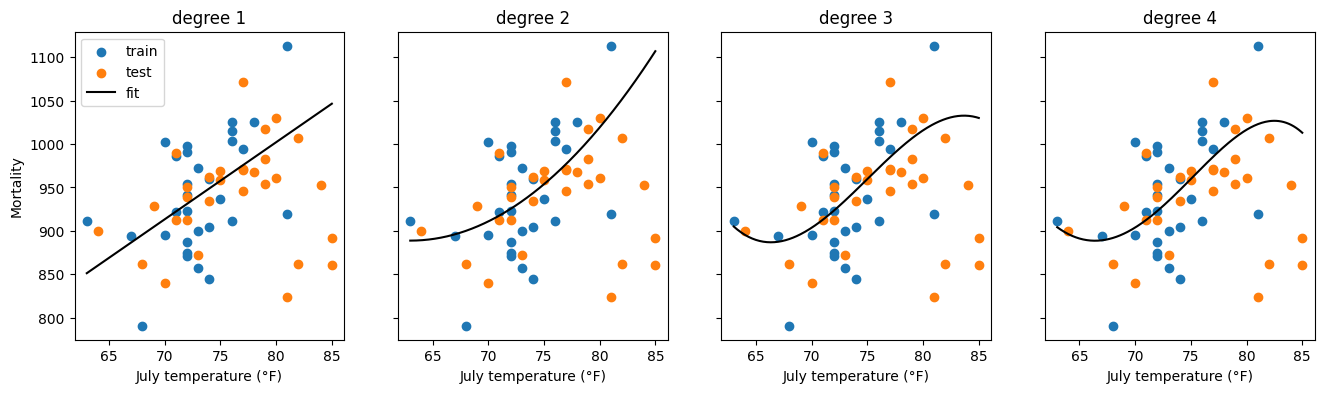

------------------------------------------------------------
Seed 5
------------------------------------------------------------


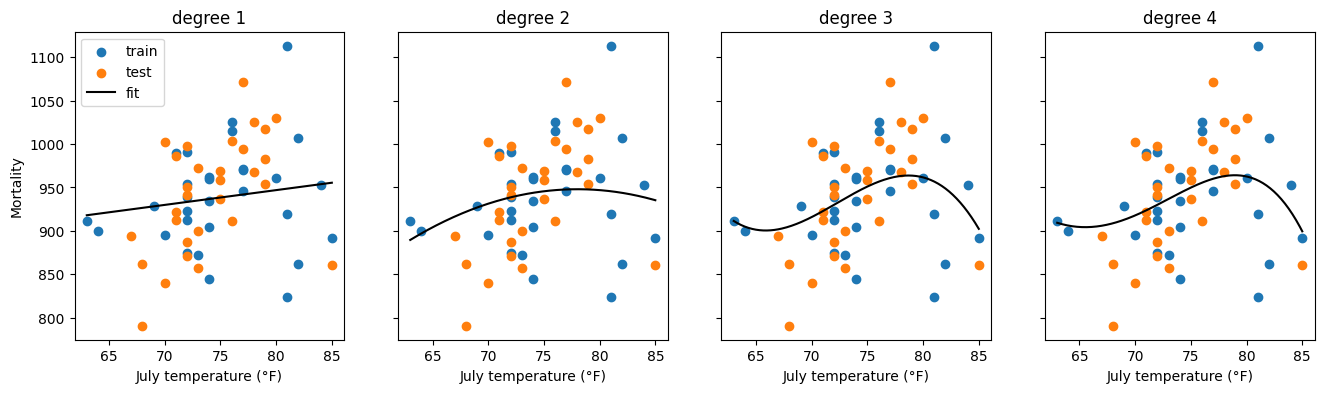

------------------------------------------------------------
Seed 6
------------------------------------------------------------


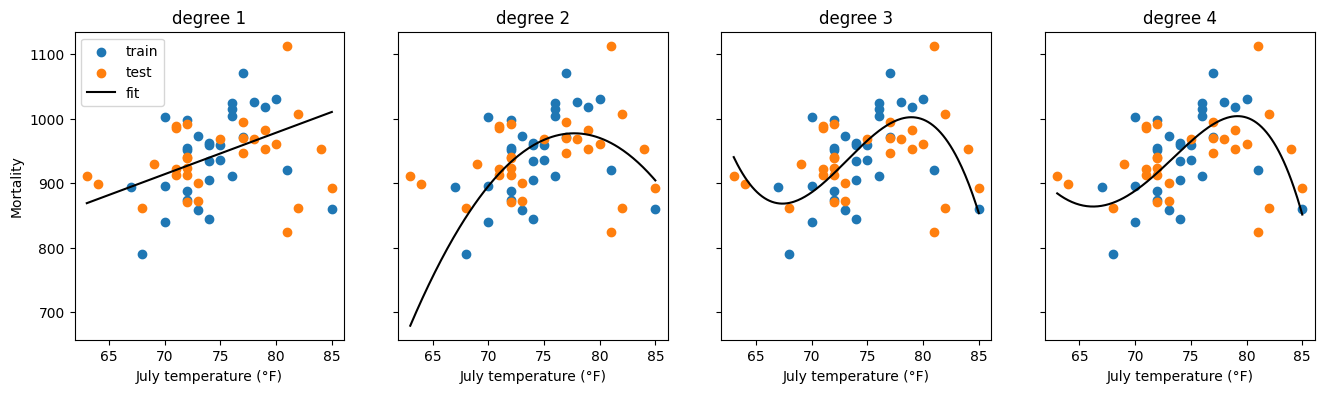

------------------------------------------------------------
Seed 7
------------------------------------------------------------


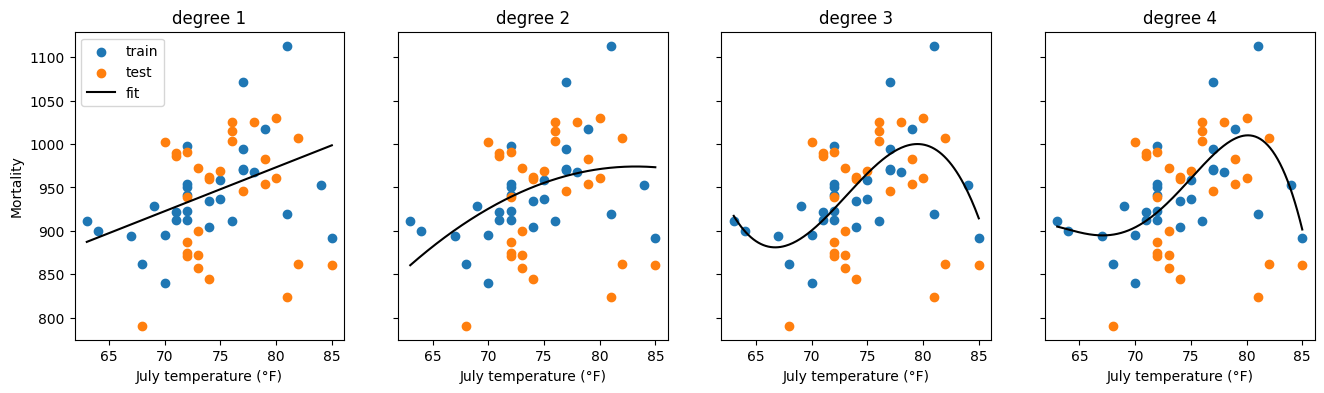

------------------------------------------------------------
Seed 8
------------------------------------------------------------


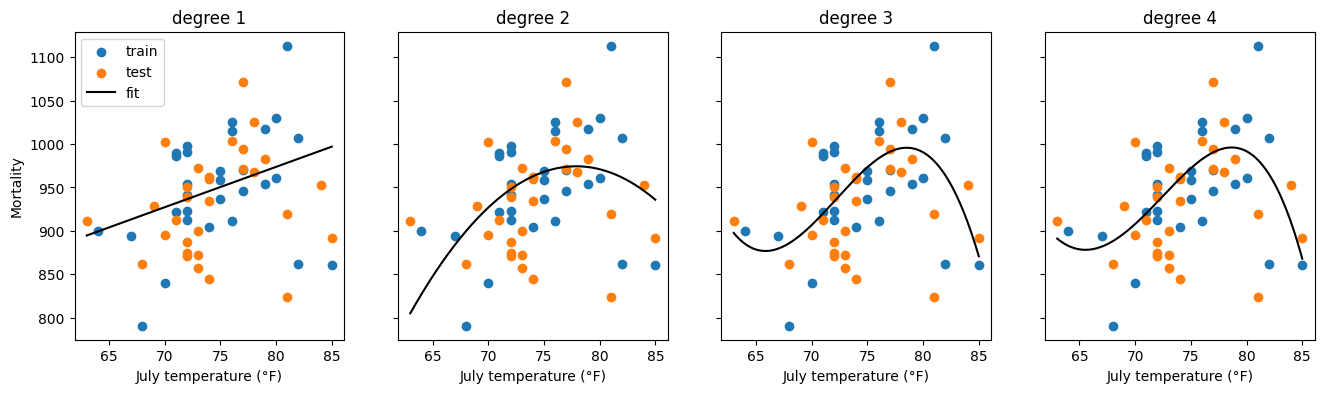

------------------------------------------------------------
Seed 9
------------------------------------------------------------


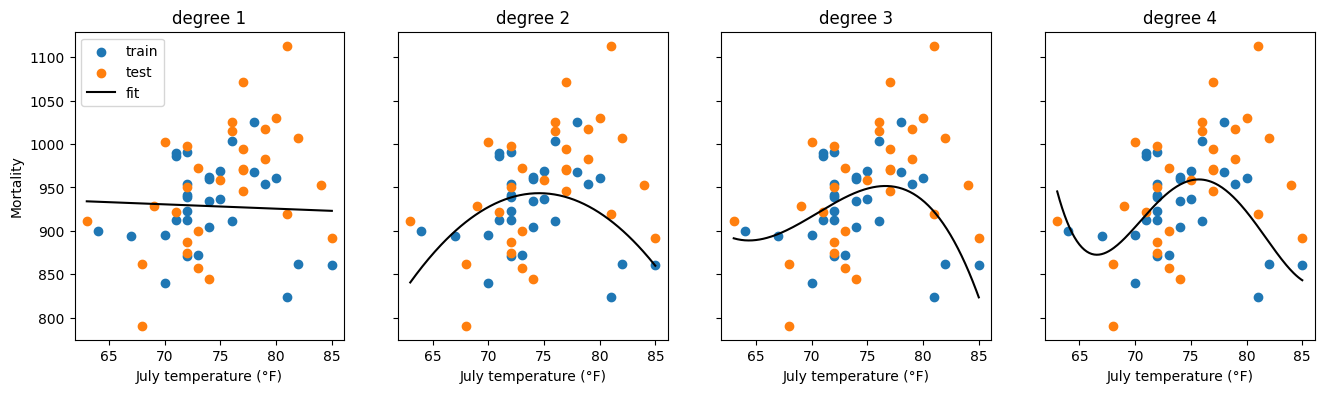

------------------------------------------------------------
Seed 10
------------------------------------------------------------


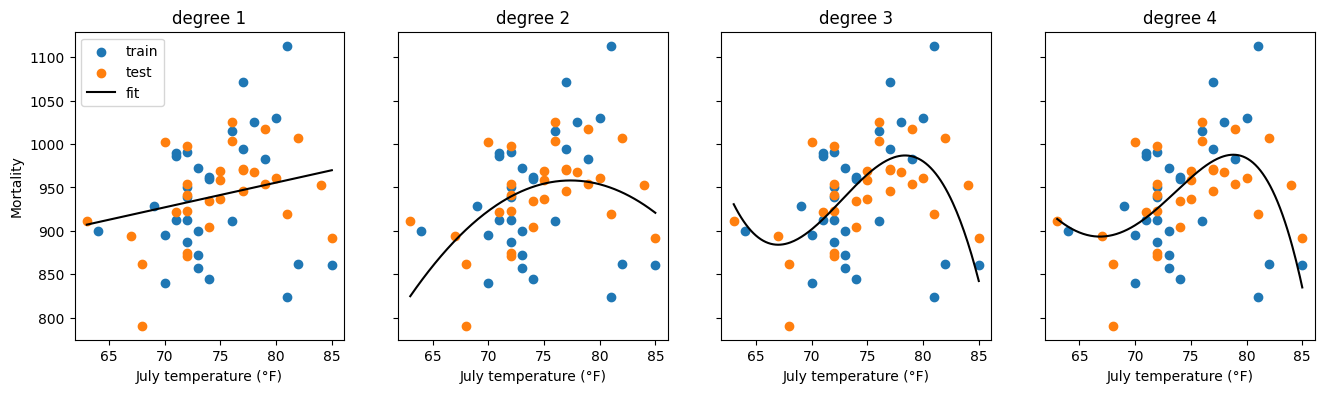

------------------------------------------------------------

Best degree per seed: [4 1 4 4 3 3 3 3 3 3]


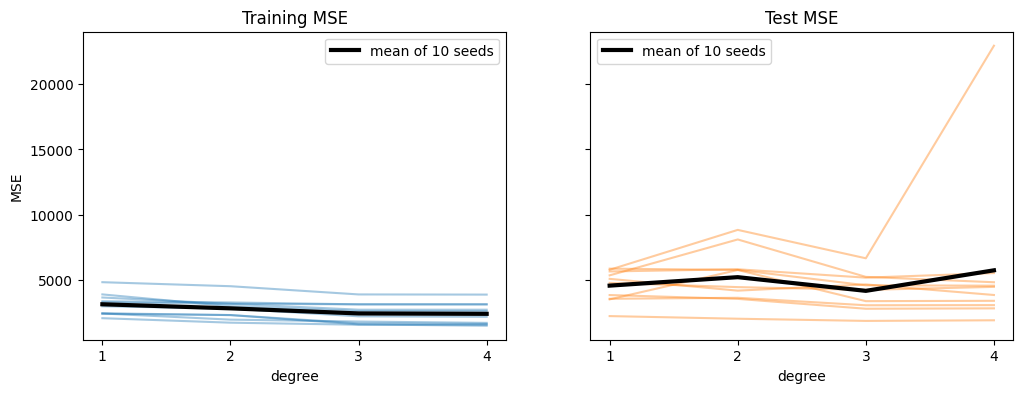

In [44]:
seeds = range(1,11)
train_all = np.zeros((10,4))
test_all = np.zeros((10,4))

for i, seed in enumerate(seeds):
  print("-"*60)
  print(f"Seed {seed}")
  print("-"*60)
  train_all[i], test_all[i] = validation_split_errors(seed, degree_list)

print("-"*60)

best = np.array(degree_list)[np.argmin(test_all, axis=1)]
print("\nBest degree per seed:", best)


fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for s in range(10):
    ax[0].plot(degree_list, train_all[s], color='tab:blue', alpha=0.4)
    ax[1].plot(degree_list, test_all[s], color='tab:orange', alpha=0.4)
ax[0].plot(degree_list, train_all.mean(axis=0), color='k', lw=3, label='mean of 10 seeds')
ax[1].plot(degree_list, test_all.mean(axis=0), color='k', lw=3, label='mean of 10 seeds')
ax[0].set_title('Training MSE')
ax[1].set_title('Test MSE')
for a in ax:
    a.set_xticks(degree_list)
    a.set_xlabel('degree')
    a.legend()
ax[0].set_ylabel('MSE')
plt.show()


Averaged over ten seeds, degree 3 slightly decreases the test error compared to degree 1 and also wins in the majority of single runs (6).

In [45]:
def kfold_mse(seed, p=3, K=3):
  rng = np.random.default_rng(seed)
  index = rng.permutation(len(xc))
  folds = np.array_split(index,K)

  fold_mse =[]
  for k in range(K):
    test = folds[k]
    train = np.concatenate([folds[i] for i in range(K) if i != k])

    coefs = np.polyfit(xc[train], y[train], p)
    fold_mse.append(mse(y[test], np.polyval(coefs, xc[test])))
  return np.array(fold_mse)

# one seed
one = kfold_mse(seed=123)
print("MSE per fold:", one)
print("3-fold estimate:", one.mean())

cv_estimate = np.array([kfold_mse(seed).mean() for seed in range(1,11)])
print("Estimate per seed", cv_estimate)
print("Mean estimate:", cv_estimate.mean())
print("Standard dev:", cv_estimate.std())

MSE per fold: [2557.60186802 4077.47985947 4141.64064648]
3-fold estimate: 3592.240791325087
Estimate per seed [3263.24480834 6833.10779044 3652.77469238 3373.43981226 3483.0748783
 2981.02297507 3396.42551497 3633.13762922 3536.40531321 3010.58887815]
Mean estimate: 3716.3222292354176
Standard dev: 1061.8846731195736


Most estimates are in a similar range at approximately 3000 to 3700. One seed however strongly diverges form this range (6833). A cubic polynominal can swing wildly at the edges of the data. If a fold happens to contain the few most extreme temperatures the model trained on the other two folds has to extrapolate beyond what it saw in the training (and performs poorly).
The effect of this outlier on the overall error could be prevented by using the median instead of the mean.

In [46]:
# Copied code from GLM ex
#----------------------------
from scipy.special import gamma
from scipy.optimize import minimize

# Load data
url = 'https://raw.githubusercontent.com/luchem/bern02/main/Labs/bird_count.csv'
data = pd.read_csv(url)

counts = np.array(data['count'])
years = np.array(data['yr']) - 1999


# Poisson regression model
def model(beta, x):

    beta0, beta1 = beta

    lam = np.exp(beta0 + beta1 * x)

    return lam


# Negative log-likelihood
def minus_log_likelihood_poisson(beta, years, counts):
    '''
    Log-likelihood for a Poisson distribution:

    The likelihood is the product of the individual probabilities.
    The log-likelihood is therefore the sum of the log-probabilities.

    To maximize the likelihood, we minimize the negative log-likelihood.
    '''

    lam = model(beta, years)

    return -np.sum(
        -lam
        + counts * np.log(lam)
        - np.log(gamma(counts + 1))
    )


# Fit model
result = minimize(
    minus_log_likelihood_poisson,
    x0=[0, 0],
    args=(years, counts)
)

beta = result.x
print("Estimated beta:", beta)
#----------------------------------------


def fit_poisson(years, counts):
  result= minimize(
        minus_log_likelihood_poisson,
        x0=[0, 0],
        args=(years, counts)
    )
  return result.x

print("sanity check")
beta_test = fit_poisson(years, counts)
print("Estimated beta:", beta_test)

Estimated beta: [ 2.32533196 -0.03244318]
sanity check
Estimated beta: [ 2.32533196 -0.03244318]


In [47]:
def bootstrap_slope(B, seed=123):
  rng = np.random.default_rng(seed)
  n = len(counts)
  slope = np.empty(B)

  for b in range(B):
    index = rng.integers(0,n,size=n) # draw WITh replacement
    beta_b = fit_poisson(years[index], counts[index])
    slope[b] = beta_b[1]
  return slope

B = 1000
slope = bootstrap_slope(B)
print("Bootstrap SE of the slope (B=1000):", slope.std(ddof=1))


Bootstrap SE of the slope (B=1000): 0.03409007499742955


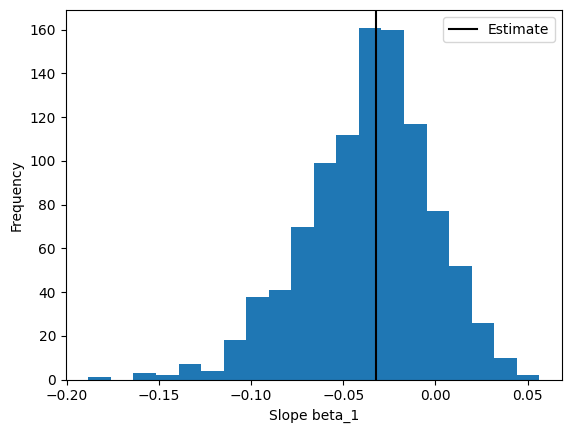

In [48]:

plt.hist(slope, bins=20)
plt.axvline(beta_test[1], color='k', label='Estimate')
plt.xlabel('Slope beta_1')
plt.ylabel('Frequency')
plt.legend()
plt.show()